# 📝 Exercise M5.01

In the previous notebook, we showed how a tree with 1 level depth works. The
aim of this exercise is to repeat part of the previous experiment for a tree
with 2 levels depth to show how such parameter affects the feature space
partitioning.

We first load the penguins dataset and split it into a training and a testing
sets:

In [1]:
import pandas as pd

penguins = pd.read_csv("../datasets/penguins_classification.csv")
culmen_columns = ["Culmen Length (mm)", "Culmen Depth (mm)"]
target_column = "Species"

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Note</p>
<p class="last">If you want a deeper overview regarding this dataset, you can refer to the
Appendix - Datasets description section at the end of this MOOC.</p>
</div>

In [2]:
from sklearn.model_selection import train_test_split

data, target = penguins[culmen_columns], penguins[target_column]
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=0
)

Create a decision tree classifier with a maximum depth of 2 levels and fit the
training data.

In [4]:
# Write your code here.
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(max_depth=2, random_state=0)
classifier.fit(data_train, target_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Now plot the data and the decision boundary of the trained classifier to see
the effect of increasing the depth of the tree.

Hint: Use the class `DecisionBoundaryDisplay` from the module
`sklearn.inspection` as shown in previous course notebooks.

<div class="admonition warning alert alert-danger">
<p class="first admonition-title" style="font-weight: bold;">Warning</p>
<p class="last">At this time, it is not possible to use <tt class="docutils literal"><span class="pre">response_method="predict_proba"</span></tt> for
multiclass problems on a single plot. This is a planned feature for a future
version of scikit-learn. In the mean time, you can use
<tt class="docutils literal"><span class="pre">response_method="predict"</span></tt> instead.</p>
</div>

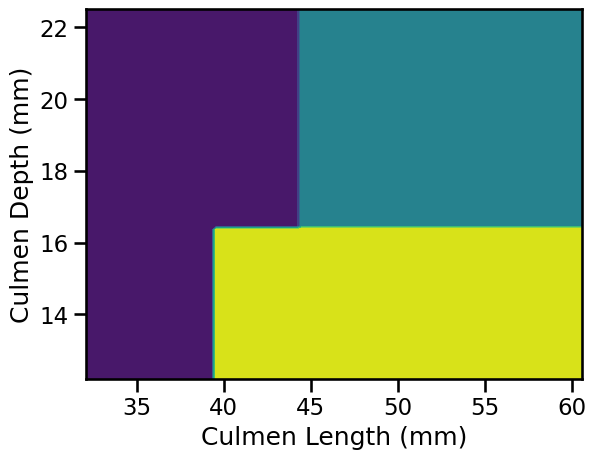

In [11]:
# Write your code here.
from sklearn.inspection import DecisionBoundaryDisplay
DecisionBoundaryDisplay.from_estimator(
    classifier,
    data_train,
    response_method="predict",
    xlabel=culmen_columns[0],
    ylabel=culmen_columns[1],
)

Did we make use of the feature "Culmen Length"? Plot the tree using the
function `sklearn.tree.plot_tree` to find out!

[Text(0.5, 0.8333333333333334, 'Culmen Depth (mm) <= 16.45\ngini = 0.642\nsamples = 256\nvalue = [107, 53, 96]\nclass = Adelie'),
 Text(0.25, 0.5, 'Culmen Length (mm) <= 39.3\ngini = 0.101\nsamples = 95\nvalue = [4, 1, 90]\nclass = Gentoo'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [4, 0, 0]\nclass = Adelie'),
 Text(0.375, 0.16666666666666666, 'gini = 0.022\nsamples = 91\nvalue = [0, 1, 90]\nclass = Gentoo'),
 Text(0.75, 0.5, 'Culmen Length (mm) <= 44.25\ngini = 0.485\nsamples = 161\nvalue = [103, 52, 6]\nclass = Adelie'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.091\nsamples = 105\nvalue = [100, 5, 0]\nclass = Adelie'),
 Text(0.875, 0.16666666666666666, 'gini = 0.281\nsamples = 56\nvalue = [3, 47, 6]\nclass = Chinstrap')]

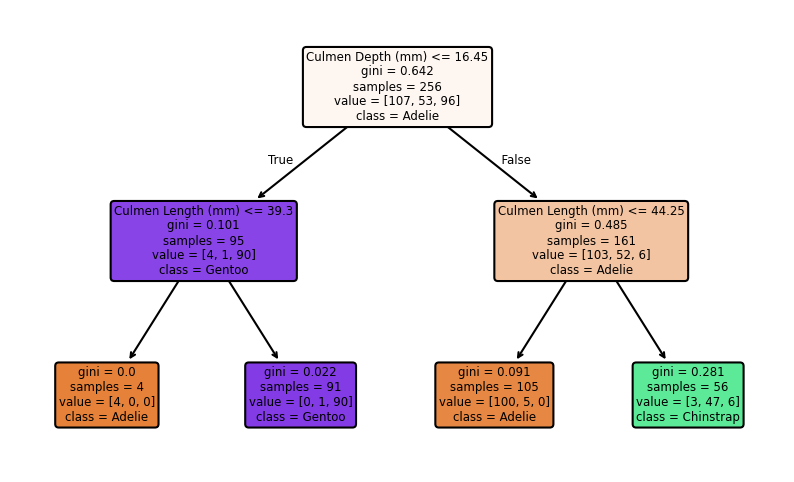

In [6]:
# Write your code here.
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_tree(
    classifier,
    feature_names=culmen_columns,
    class_names=classifier.classes_,
    filled=True,
    rounded=True,
)

Compute the accuracy of the decision tree on the testing data.

In [7]:
# Write your code here.
classifier.score(data_test, target_test)

0.9651162790697675